1. 看下MPI中的allreduce， ring-allreduce这两个操作，顺便看下broadcast，gathering等相关操作
2. 了解下pytorch的DDP函数，全称 distributed data  parallel
3. 解释下，如果我们是用4张GPU卡训练的话，为什么训练效率不是1张卡训练的4倍，有哪些影响因素
4. 去查资料了解下： delay update或accumulate gradient

## Allreduce

**MPI（Message Passing Interface，通信接口）** ，存在于同一台与不同台计算机的进程与进程间。



**Allreduce（全局规约）** ，将 **所有进程** 的数据进行 **逐元素规约** （求和/求最大等），然后将结果返回给所有进程。

在 12.5 中的多GPU训练中，$k$ 个GPU并行训练过程如下:

- 在任何一次训练迭代中，给定的随机的小批量样本都将被分成 $k$ 个部分，并均匀地分配到GPU上
- 每个GPU根据分配给它的小批量子集，计算模型参数的损失和梯度
- 将 $k$ 个GPU中的局部梯度聚合，以获得当前小批量的随机梯度
- 聚合梯度被重新分发到每个GPU中
- 每个GPU使用这个小批量随机梯度，来更新它所维护的完整的模型参数集，即 **每个GPU更新梯度用的就是所有GPU中的局部梯度的平均** 

跨多个设备对参数求平均然后分发结果的操作就是 Allreduce 。在实际中，每个进程有自己的 tensor 。



1. 朴素实现：

Allreduce 的朴素实现就是在某一个特定 GPU （或 CPU）上聚合梯度然后分发。


2. **ring-allreduce** ：

ring-allreduce 将通信组织成环状， **每个进程只与相邻进程通信** 。

假设有 N 个 GPU，每个 GPU 有 d 维数据：

阶段1: Reduce-Scatter（分散规约）
- 迭代 N-1 次
- 每次每个 GPU 发送 d/N 维度给下一个 GPU
- 接收并累加

阶段2: All-Gather（全收集）
- 迭代 N-1 次  
- 每个 GPU 收集完整的规约结果

这样，每个 GPU 直接进行 求和 操作。



朴素的 Allreduce 可以用 Broadcast + Gather 来实现，但broadcast 和 Gather 作为独立操作，有自己的高效实现。

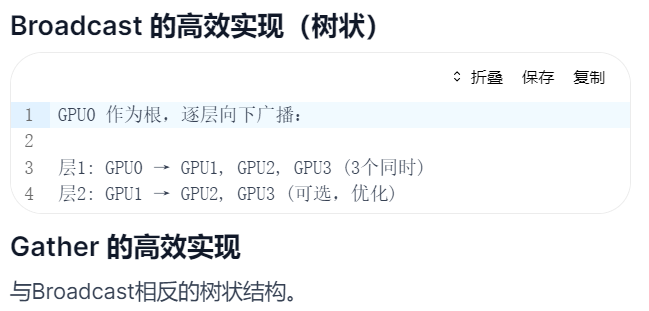

## DDP

12.5 中的 `nn.DataParalled()` 如果要执行多 GPU 并行训练，是基于上面的 allreduce 的朴素实现。而 `DDP()` 是基于 ring-allreduce 的。

```python 
from torch.nn.parallel import DistributedDataParallel as DDP

ddp_model = DDP(
    module,                      # 要包装的模型
    device_ids=[rank],           # 当前设备的ID列表
    output_device=rank,          # 输出设备
    dim=0,                       # 数据维度（默认0）
    broadcast_buffers=True,      # 是否广播buffers（BN等）
    broadcast_buffers=True,      # 同步BN的running_mean/running_var
    find_unused_parameters=False,# 是否检测未使用的参数（调试用）
    gradient_as_bucket_view=True # 梯度是否共享内存
)
```

## 训练效率

最显然的是，如果效率是一张卡的四倍的话，那么数据传输时间忽略为0。通信与数据加载是最主要的影响因素。因为一般情况下均分小批量数据到各个卡上，如果卡的性能不一样，有的卡需要同步等待。除此以外，额外操作如 allreduce 也需要耗时，不过这种耗时与通信耗时重合。

## Delay Update 与 Gradient Accumulation

把多个小batch的梯度累积起来，等效于使用更大的batch再更新参数。

普通更新（每步通信）:
每次迭代都要执行 AllReduce 同步梯度
通信开销 = O(迭代次数)

延迟更新（每k步通信）:
每k次迭代才通信一次
通信开销 = O(迭代次数/k)
